In [9]:
import numpy as np
import pandas as pd
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'

raw = pd.read_csv('http://hilpisch.com/pyalgo_eikon_eod_data.csv',
                   index_col=0, parse_dates=True).dropna()

data = pd.DataFrame(raw['EUR='])
data.rename(columns={'EUR=': 'price'}, inplace=True)

data['SMA1'] = data['price'].rolling(42).mean()
data['SMA2'] = data['price'].rolling(252).mean()
data.tail()


,price,SMA1,SMA2
Date,,,
2019-12-24,1.1087,1.107698,1.119630
2019-12-26,1.1096,1.107740,1.119529
2019-12-27,1.1175,1.107924,1.119428
2019-12-30,1.1197,1.108131,1.119333
2019-12-31,1.1210,1.108279,1.119231


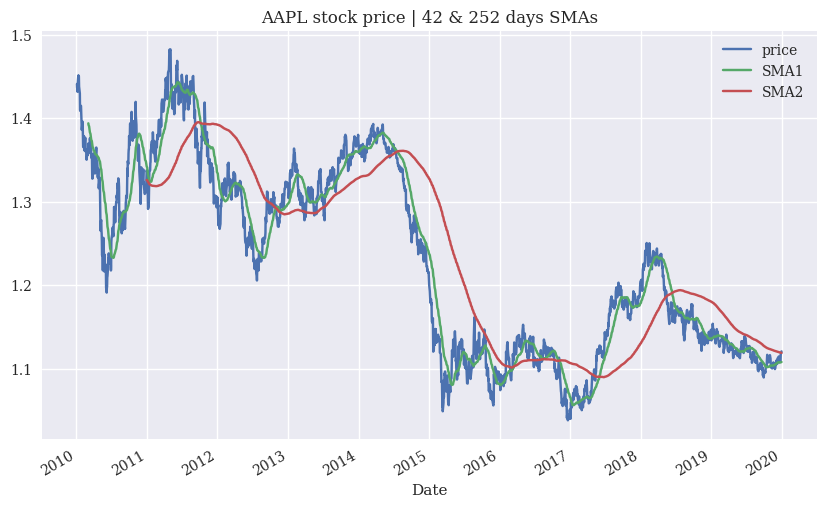

In [10]:
data.plot(title='AAPL stock price | 42 & 252 days SMAs',figsize=(10, 6));

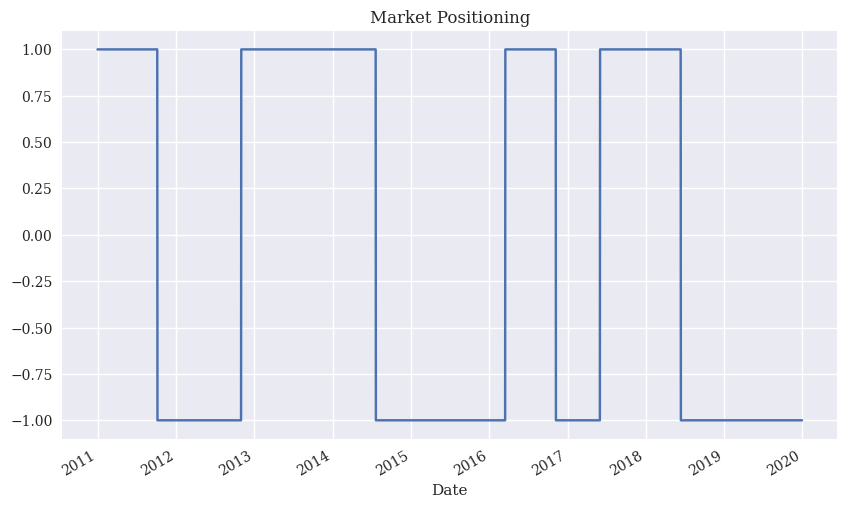

In [12]:
data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
data.dropna(inplace=True)

data['position'].plot(ylim=[-1.1, 1.1], title='Market Positioning', figsize=(10, 6));

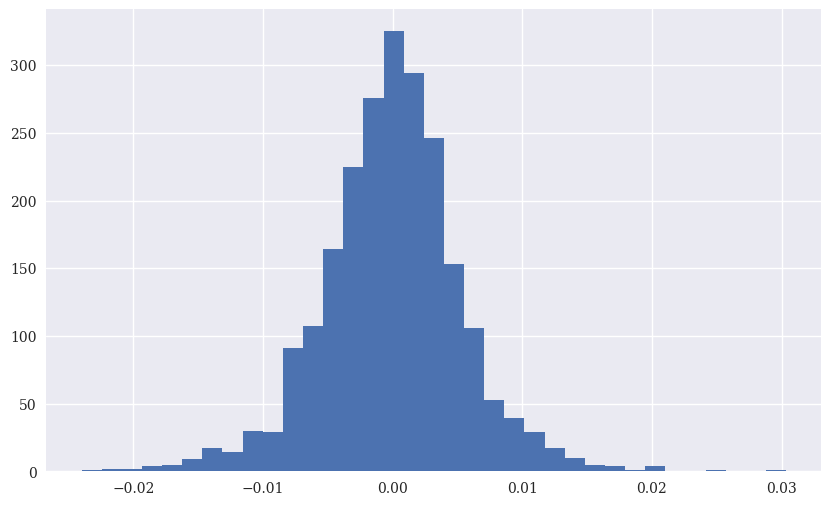

In [13]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))
data['returns'].hist(bins=35, figsize=(10, 6));

In [14]:
data['strategy'] = data['position'].shift(1) * data['returns']
data[['returns', 'strategy']].sum()

returns    -0.176731
strategy    0.253121
dtype: float64

In [15]:
data[['returns', 'strategy']].sum().apply(np.exp)

returns     0.838006
strategy    1.288039
dtype: float64

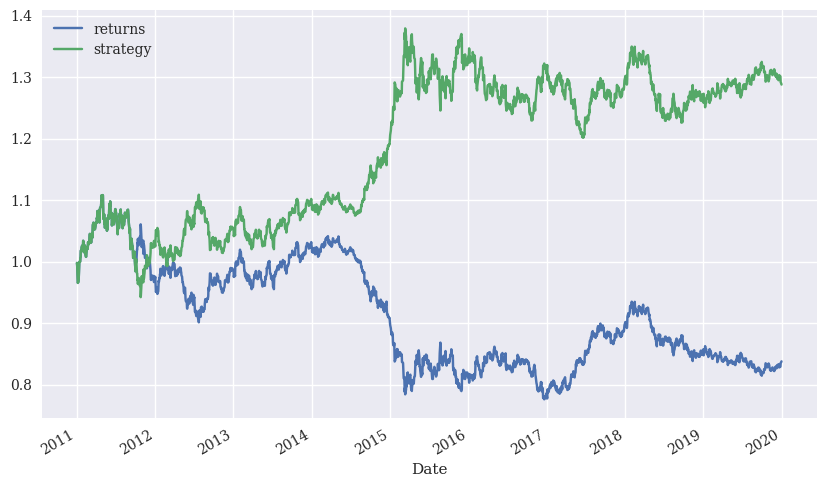

In [16]:
data[['returns', 'strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(10, 6));

In [17]:
data[['returns', 'strategy']].mean() * 252

returns    -0.019671
strategy    0.028174
dtype: float64

In [18]:
data[['returns', 'strategy']].std() * 252 ** 0.5

returns     0.085414
strategy    0.085405
dtype: float64

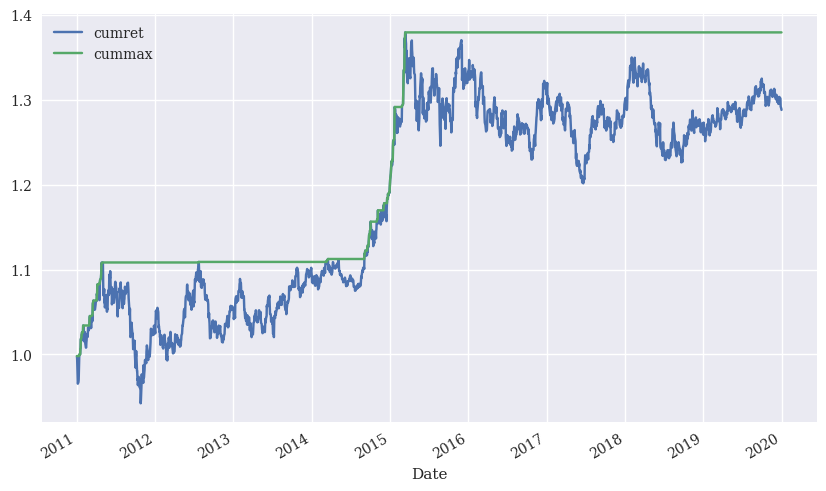

In [19]:
data['cumret'] = data['strategy'].cumsum().apply(np.exp)
data['cummax'] = data['cumret'].cummax()
data[['cumret', 'cummax']].dropna().plot(figsize=(10, 6));

In [21]:
drawdown = data['cummax'] - data['cumret']
drawdown.max()

0.17779367070195895

In [25]:
# Dates when cummax and cumret intersect (data['cummax'] - data['cumret'] = 0)
temp = drawdown[drawdown == 0]
temp

Date
2011-01-03    0.0
2011-01-13    0.0
2011-01-14    0.0
2011-01-18    0.0
2011-01-19    0.0
             ... 
2015-03-05    0.0
2015-03-06    0.0
2015-03-10    0.0
2015-03-11    0.0
2015-03-13    0.0
Length: 76, dtype: float64

In [27]:
#Calculate timedelta values all index values
periods = (temp.index[1:].to_pydatetime() - temp.index[:-1].to_pydatetime())
periods

array([datetime.timedelta(days=10), datetime.timedelta(days=1),
       datetime.timedelta(days=4), datetime.timedelta(days=1),
       datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=3), datetime.timedelta(days=1),
       datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=5), datetime.timedelta(days=29),
       datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=10), datetime.timedelta(days=1),
       datetime.timedelta(days=2), datetime.timedelta(days=1),
       datetime.timedelta(days=3), datetime.timedelta(days=11),
       datetime.timedelta(days=5), datetime.timedelta(days=2),
       datetime.timedelta(days=6), datetime.timedelta(days=6),
       datetime.timedelta(days=1), datetime.timedelta(days=4),
       datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=1), datetime.timedelta(days=4),
       datetime.timedelta(days=1), datetime.timedel

In [28]:
periods[12:15]

array([datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=10)], dtype=object)

In [29]:
periods.max()

datetime.timedelta(days=596)